## Compare Cellpose3/Cellpose4 cyto3/cpsam

Cellpose version: 4.0.8 (major number: 4)


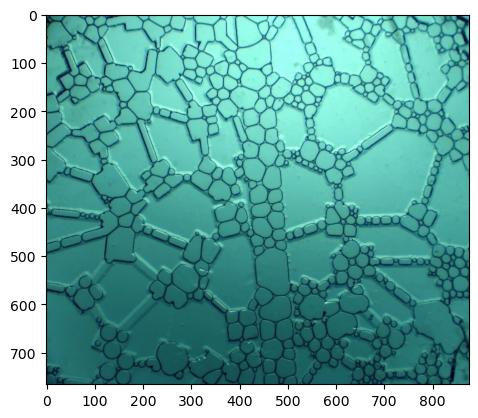

In [1]:
from skimage.io import imread
from pathlib import Path
from matplotlib import pyplot as plt
import cellpose

image = imread("/home/bnorthan/images/tnia-python-images/imagesc/2026_04_30_bubble_in_image_j/4b4251c7-17f5-4b8c-a217-8af293f0f93e (1).jpg")

plt.imshow(image)

major_number = cellpose.version.split('.')[0]
print(f"Cellpose version: {cellpose.version} (major number: {major_number})")


model_type argument is not used in v4.0.1+. Ignoring this argument...


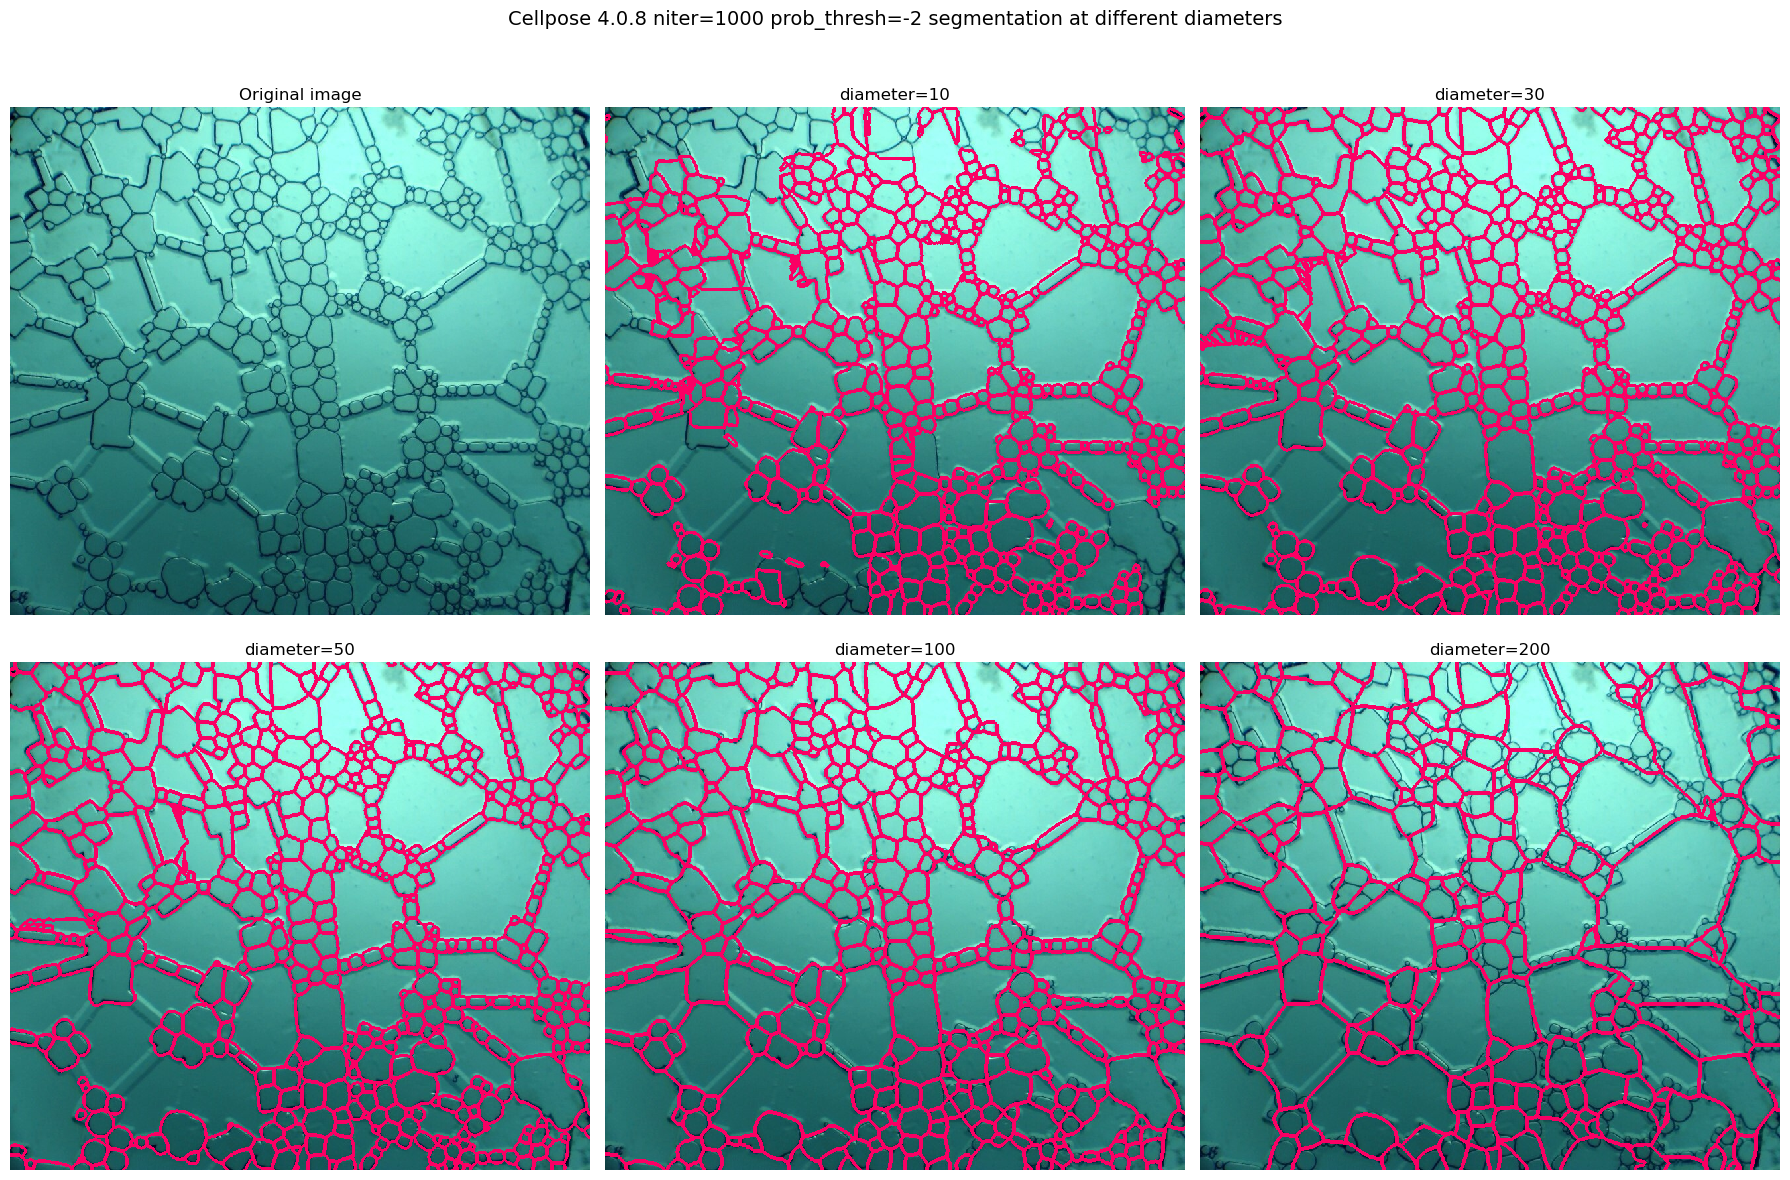

In [4]:
from cellpose import models 
from tnia.plotting.plt_helper import mask_outline_overlay

model = models.CellposeModel(gpu=True, model_type='cyto3')

color = [250, 0, 100]

diameters = [10, 30, 50, 100, 200]

niters = [1000]

prob_thresh = [-2]

results = {}
for p in prob_thresh:
    for niter in niters:
        for d in diameters:
            r = model.eval(image, diameter=d, cellprob_threshold=p, flow_threshold=2.5, niter=niter)
            results[d] = r[0]

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Original image')
        axes[0].axis('off')

        for ax, (d, mask) in zip(axes[1:], results.items()):
            outlines = mask_outline_overlay(image, mask, color=color, thickness=3)
            ax.imshow(outlines)
            ax.set_title(f'diameter={d}')
            ax.axis('off')

        plt.suptitle(f'Cellpose {cellpose.version} niter={niter} prob_thresh={p} segmentation at different diameters', fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()